### YOLO v11 on my dataset
This code fine tunes the well developed YOLO v11 model to my dataset and annotations, I train the model and use certain metrics to track and evaluate the models performance

In [ ]:
# checking if GPU is availble --- to speed up training speed
!nvidia-smi

Thu Dec 19 09:53:24 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off | 00000000:00:04.0 Off |                    0 |
| N/A   31C    P0              41W / 400W |      2MiB / 40960MiB |      0%      Default |
|                                         |                      |             Disabled |
+-----------------------------------------+----------------------+--

In [ ]:
# installing ultralytics
%pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.3.51 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA A100-SXM4-40GB, 40514MiB)
Setup complete ✅ (12 CPUs, 83.5 GB RAM, 32.9/235.7 GB disk)


In [ ]:
# mount Google Drive so we can access our dataset(training, testing and validation images)
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# downloading testing data from kaggle
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aryashah2k/potholenet")

print("Path to dataset files:", path)

100%|██████████| 986M/986M [00:18<00:00, 54.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/aryashah2k/potholenet/versions/1


In [ ]:
import os
import xml.etree.ElementTree as ET

# Paths
xml_dir = '/content/drive/MyDrive/Dataset/Testing/Pictures/Dublin/anno'  # Path to XML annotations
txt_dir = '/content/drive/MyDrive/Dataset/Testing/Pictures/Dublin/x.labels'       # Path to save TXT files
images_dir = '/content/drive/MyDrive/Dataset/Testing/Pictures/Dublin/images'    # Path to images

# Create labels directory if it doesn't exist
os.makedirs(txt_dir, exist_ok=True)

# Classes (update based on your dataset)
classes = ['pothole']

# Conversion function
def convert_xml_to_yolo(xml_file, txt_file, image_dir):
    tree = ET.parse(xml_file)
    root = tree.getroot()
    image_width = int(root.find("size/width").text)
    image_height = int(root.find("size/height").text)

    with open(txt_file, "w") as txt:
        for obj in root.findall("object"):
            class_name = obj.find("name").text
            if class_name not in classes:
                continue
            class_id = classes.index(class_name)

            # Get bounding box coordinates
            xmin = int(obj.find("bndbox/xmin").text)
            ymin = int(obj.find("bndbox/ymin").text)
            xmax = int(obj.find("bndbox/xmax").text)
            ymax = int(obj.find("bndbox/ymax").text)

            # Normalize coordinates
            x_center = ((xmin + xmax) / 2) / image_width
            y_center = ((ymin + ymax) / 2) / image_height
            width = (xmax - xmin) / image_width
            height = (ymax - ymin) / image_height

            # Write to TXT file
            txt.write(f"{class_id} {x_center} {y_center} {width} {height}\n")

# Loop through XML files and convert
for xml_file in os.listdir(xml_dir):
    if not xml_file.endswith('.xml'):
        continue
    base_name = os.path.splitext(xml_file)[0]
    txt_file = os.path.join(txt_dir, f"{base_name}.txt")
    convert_xml_to_yolo(os.path.join(xml_dir, xml_file), txt_file, images_dir)

print("Conversion complete! Check the labels directory.")


Conversion complete! Check the labels directory.


In [ ]:
import os
import xml.etree.ElementTree as ET

# Paths
xml_dir = '/content/drive/MyDrive/Dataset/Testing/Pictures/Cranfield/Cranfield300 labels'
txt_dir = '/content/drive/MyDrive/Dataset/Testing/Pictures/Cranfield/300x.labels'
images_dir = '/content/drive/MyDrive/Dataset/Testing/Pictures/Cranfield/Cranfield300'

# Create labels directory if it doesn't exist
os.makedirs(txt_dir, exist_ok=True)

# Classes (update based on your dataset)
classes = ['pothole']

# Conversion function
def convert_xml_to_yolo(xml_file, txt_file, image_dir):
    try:
        tree = ET.parse(xml_file)
        root = tree.getroot()
        image_width = int(root.find("size/width").text)
        image_height = int(root.find("size/height").text)

        with open(txt_file, "w") as txt:
            for obj in root.findall("object"):
                class_name = obj.find("name").text
                if class_name not in classes:
                    continue
                class_id = classes.index(class_name)

                # Get bounding box coordinates
                xmin = int(obj.find("bndbox/xmin").text)
                ymin = int(obj.find("bndbox/ymin").text)
                xmax = int(obj.find("bndbox/xmax").text)
                ymax = int(obj.find("bndbox/ymax").text)

                # Normalize coordinates
                x_center = ((xmin + xmax) / 2) / image_width
                y_center = ((ymin + ymax) / 2) / image_height
                width = (xmax - xmin) / image_width
                height = (ymax - ymin) / image_height

                # Write to TXT file
                txt.write(f"{class_id} {x_center} {y_center} {width} {height}\n")
    except Exception as e:
        print(f"Error processing file {xml_file}: {e}")

# Loop through XML files and convert
for xml_file in os.listdir(xml_dir):
    if not xml_file.endswith('.xml'):
        continue
    base_name = os.path.splitext(xml_file)[0]
    txt_file = os.path.join(txt_dir, f"{base_name}.txt")
    convert_xml_to_yolo(os.path.join(xml_dir, xml_file), txt_file, images_dir)

print("Conversion complete! Check the labels directory.")


Conversion complete! Check the labels directory.


In [ ]:
import os
import xml.etree.ElementTree as ET

# Paths
xml_dir = '/content/drive/MyDrive/Dataset/Testing/Pictures/Dublin/Dublin Day light anno'
txt_dir = '/content/drive/MyDrive/Dataset/Testing/Pictures/Dublin/1x.labels'
images_dir = '/content/drive/MyDrive/Dataset/Testing/Pictures/Dublin/Dublin Day Light'

# Create labels directory if it doesn't exist
os.makedirs(txt_dir, exist_ok=True)

# Classes (update based on your dataset)
classes = ['pothole']

# Conversion function
def convert_xml_to_yolo(xml_file, txt_file, image_dir):
    tree = ET.parse(xml_file)
    root = tree.getroot()
    image_width = int(root.find("size/width").text)
    image_height = int(root.find("size/height").text)

    with open(txt_file, "w") as txt:
        for obj in root.findall("object"):
            class_name = obj.find("name").text
            if class_name not in classes:
                continue
            class_id = classes.index(class_name)

            # Get bounding box coordinates
            xmin = int(obj.find("bndbox/xmin").text)
            ymin = int(obj.find("bndbox/ymin").text)
            xmax = int(obj.find("bndbox/xmax").text)
            ymax = int(obj.find("bndbox/ymax").text)

            # Normalize coordinates
            x_center = ((xmin + xmax) / 2) / image_width
            y_center = ((ymin + ymax) / 2) / image_height
            width = (xmax - xmin) / image_width
            height = (ymax - ymin) / image_height

            # Write to TXT file
            txt.write(f"{class_id} {x_center} {y_center} {width} {height}\n")

# Loop through XML files and convert
for xml_file in os.listdir(xml_dir):
    if not xml_file.endswith('.xml'):
        continue
    base_name = os.path.splitext(xml_file)[0]
    txt_file = os.path.join(txt_dir, f"{base_name}.txt")
    convert_xml_to_yolo(os.path.join(xml_dir, xml_file), txt_file, images_dir)

print("Conversion complete! Check the labels directory.")

Conversion complete! Check the labels directory.


In [ ]:
!export LC_ALL=C.UTF-8
!export LANG=C.UTF-8


NotImplementedError: A UTF-8 locale is required. Got ANSI_X3.4-1968

In [ ]:
!yolo task=detect mode=train model=yolov8x.pt data=/content/drive/MyDrive/Dataset/data.yaml/data.yaml lr0=0.001 epochs=85 imgsz=1024 batch=16 name=pothole_yolo_train device=0

Ultralytics 8.3.51 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA A100-SXM4-40GB, 40514MiB)
engine/trainer: task=detect, mode=train, model=yolov8x.pt, data=/content/drive/MyDrive/Dataset/data.yaml/data.yaml, epochs=85, time=None, patience=100, batch=16, imgsz=1024, save=True, save_period=-1, cache=False, device=0, workers=8, project=None, name=pothole_yolo_train6, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=Fa

In [ ]:
import shutil

# Source path: Replace with the path to your trained model
source = "/content/runs/detect/val3"

# Destination path: Replace with your desired destination folder in Drive
destination = "/content/drive/MyDrive/Dataset"

# Copy the model file
shutil.copy(source, destination)

print(f"Model uploaded to {destination}")


IsADirectoryError: [Errno 21] Is a directory: '/content/runs/detect/val3'

In [ ]:
from ultralytics import YOLO

# Load YOLOv8
model = YOLO('yolov8l.pt')  # Yolov8 Large
# Train on your pothole dataset
model.train(
    data='/content/drive/MyDrive/Dataset/data.yaml/data.yaml',  # Path to data.yaml
    epochs=50,  # Number of epochs
    imgsz=640,  # Image size
    batch=8,    # Batch size
    name='pothole_yolo_train',  #
    device=1    # GPU
)


Ultralytics 8.3.51 🚀 Python-3.10.12 torch-2.5.1+cu121 


ValueError: Invalid CUDA 'device=1' requested. Use 'device=cpu' or pass valid CUDA device(s) if available, i.e. 'device=0' or 'device=0,1,2,3' for Multi-GPU.

torch.cuda.is_available(): False
torch.cuda.device_count(): 0
os.environ['CUDA_VISIBLE_DEVICES']: None
See https://pytorch.org/get-started/locally/ for up-to-date torch install instructions if no CUDA devices are seen by torch.


In [ ]:
yolo task=detect mode=predict model=/content/runs/detect/pothole_yolo_train/weights/best.pt data=/content/drive/MyDrive/pothole_data_test_yaml/pothole_data_yaml.yaml

SyntaxError: invalid syntax (<ipython-input-4-e8c85fe60ce4>, line 1)

In [ ]:
import shutil

# Set the paths for your model and destination in Google Drive
source_path = '/content/runs/detect/pothole_yolo_train6/weights/best.pt'  # or 'last.pt'
destination_path = '/content/drive/MyDrive/Dataset/best.pt6'  # Adjust this path as needed

# Copy the model to Google Drive
shutil.copy(source_path, destination_path)
print(f'Model saved to {destination_path}')


Model saved to /content/drive/MyDrive/Dataset/best.pt6


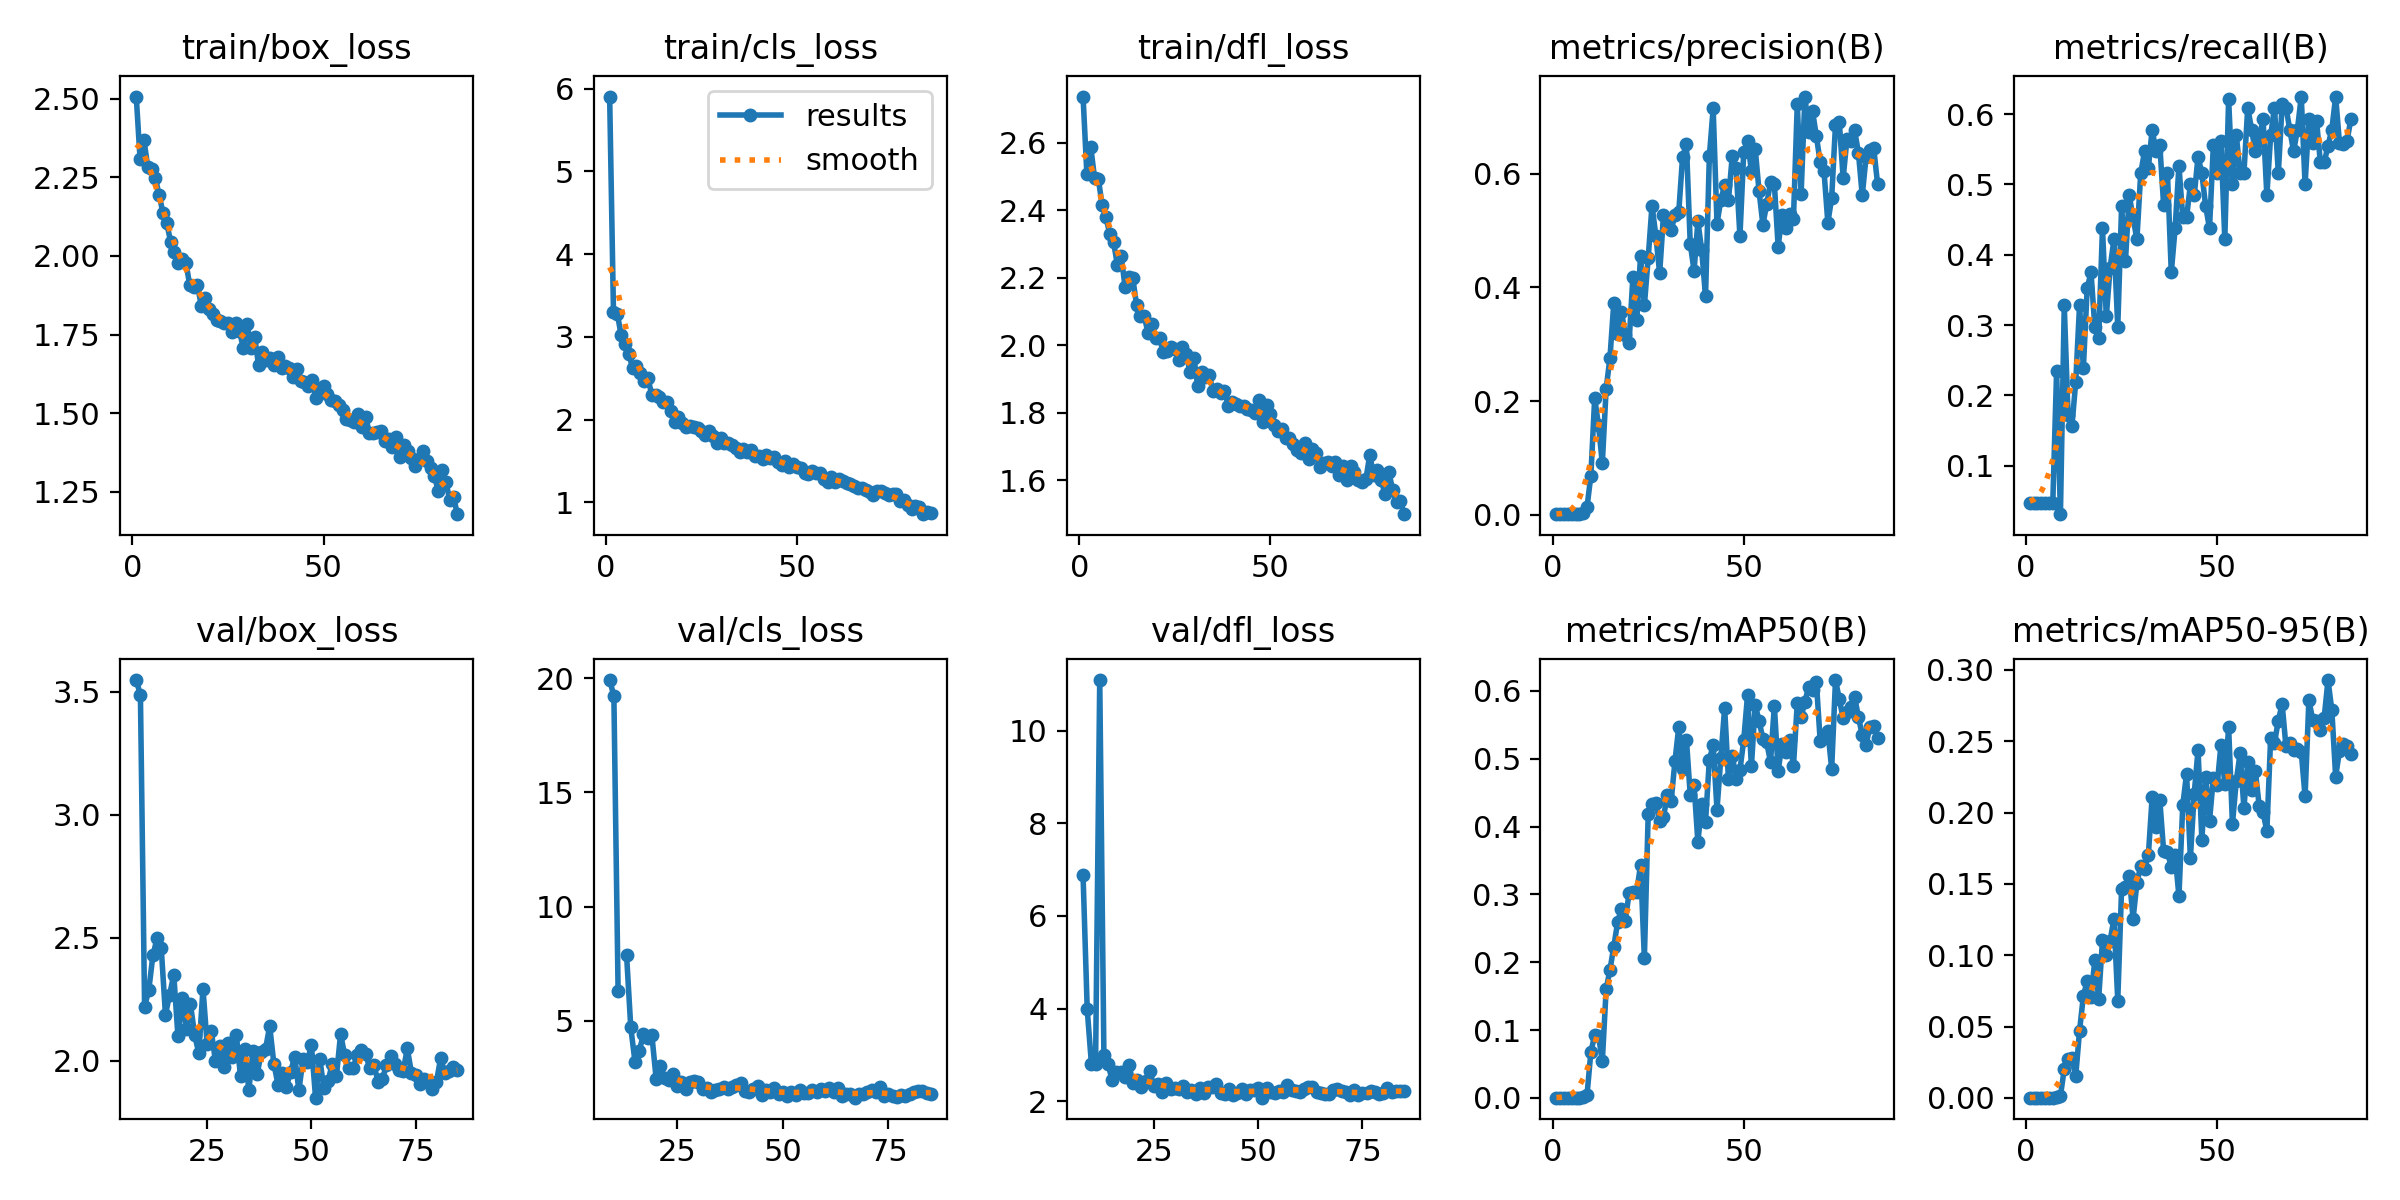

In [ ]:
Image(filename=F'/content/runs/detect/pothole_yolo_train6/results.png')

In [ ]:
!yolo task=detect mode=val model=/content/runs/detect/pothole_yolo_train6/weights/best.pt source=/content/drive/MyDrive/Dataset/data.yaml/data.yaml imgsz=800 device=0

WARNING ⚠️ 'data' argument is missing. Using default 'data=coco8.yaml'.
Ultralytics 8.3.51 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA A100-SXM4-40GB, 40514MiB)
Model summary (fused): 268 layers, 68,125,494 parameters, 0 gradients, 257.4 GFLOPs

Dataset 'coco8.yaml' images not found ⚠️, missing path '/content/datasets/coco8/images/val'
100% 433k/433k [00:00<00:00, 54.8MB/s]
Unzipping /content/datasets/coco8.zip to /content/datasets/coco8...: 100% 25/25 [00:00<00:00, 4281.13file/s]
Dataset download success ✅ (1.8s), saved to /content/datasets

val: Scanning /content/datasets/coco8/labels/val... 4 images, 0 backgrounds, 0 corrupt: 100% 4/4 [00:00<00:00, 544.50it/s]
val: New cache created: /content/datasets/coco8/labels/val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95):   0% 0/1 [00:00<?, ?it/s]
Traceback (most recent call last):
  File "/usr/local/bin/yolo", line 8, in <module>
    sys.exit(entrypoint())
  File "/usr/local/lib/python

In [ ]:
import os
from ultralytics import YOLO
from IPython.display import display, Image
from IPython import display
display.clear_output()
!yolo mode=checks

Traceback (most recent call last):
  File "/usr/local/bin/yolo", line 8, in <module>
    sys.exit(entrypoint())
  File "/usr/local/lib/python3.10/dist-packages/ultralytics/cfg/__init__.py", line 911, in entrypoint
    raise ValueError(f"Invalid 'mode={mode}'. Valid modes are {MODES}.\n{CLI_HELP_MSG}")
ValueError: Invalid 'mode=<module 'ultralytics.utils.checks' from '/usr/local/lib/python3.10/dist-packages/ultralytics/utils/checks.py'>'. Valid modes are {'train', 'predict', 'export', 'val', 'benchmark', 'track'}.

    Arguments received: ['yolo', 'mode=checks']. Ultralytics 'yolo' commands use the following syntax:

        yolo TASK MODE ARGS

        Where   TASK (optional) is one of {'classify', 'segment', 'obb', 'detect', 'pose'}
                MODE (required) is one of {'train', 'predict', 'export', 'val', 'benchmark', 'track'}
                ARGS (optional) are any number of custom 'arg=value' pairs like 'imgsz=320' that override defaults.
                    See all ARGS at ht

In [ ]:
!yolo task=detect mode=val model=/content/runs/detect/pothole_yolo_train6/weights/best.pt data=/content/drive/MyDrive/Dataset/data.yaml/data.yaml imgsz=640 batch=16 device=0

Ultralytics 8.3.51 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA A100-SXM4-40GB, 40514MiB)
Model summary (fused): 268 layers, 68,124,531 parameters, 0 gradients, 257.4 GFLOPs
val: Scanning /root/.cache/kagglehub/datasets/rajdalsaniya/pothole-detection-dataset/versions/1/train/labels... 0 images, 2067 backgrounds, 0 corrupt: 100% 2067/2067 [00:01<00:00, 1843.66it/s]
val: WARNING ⚠️ No labels found in /root/.cache/kagglehub/datasets/rajdalsaniya/pothole-detection-dataset/versions/1/train/labels.cache. See https://docs.ultralytics.com/datasets for dataset formatting guidance.
val: New cache created: /root/.cache/kagglehub/datasets/rajdalsaniya/pothole-detection-dataset/versions/1/train/labels.cache
WARNING ⚠️ No labels found in /root/.cache/kagglehub/datasets/rajdalsaniya/pothole-detection-dataset/versions/1/train/labels.cache, training may not work correctly. See https://docs.ultralytics.com/datasets for dataset formatting guidance.
                 Class     Images  Instances      B

In [ ]:
!yolo task=detect mode=val model=/content/runs/detect/pothole_yolo_train/weights/best.pt data=/content/drive/MyDrive/Dataset/data.yaml/data.yaml imgsz=640 batch=16 device=0


Ultralytics 8.3.51 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA A100-SXM4-40GB, 40514MiB)
Model summary (fused): 268 layers, 43,608,150 parameters, 0 gradients, 164.8 GFLOPs
val: Scanning /root/.cache/kagglehub/datasets/rajdalsaniya/pothole-detection-dataset/versions/1/train/labels... 0 images, 2067 backgrounds, 0 corrupt: 100% 2067/2067 [00:01<00:00, 1834.63it/s]
val: WARNING ⚠️ No labels found in /root/.cache/kagglehub/datasets/rajdalsaniya/pothole-detection-dataset/versions/1/train/labels.cache. See https://docs.ultralytics.com/datasets for dataset formatting guidance.
val: New cache created: /root/.cache/kagglehub/datasets/rajdalsaniya/pothole-detection-dataset/versions/1/train/labels.cache
WARNING ⚠️ No labels found in /root/.cache/kagglehub/datasets/rajdalsaniya/pothole-detection-dataset/versions/1/train/labels.cache, training may not work correctly. See https://docs.ultralytics.com/datasets for dataset formatting guidance.
                 Class     Images  Instances      B

In [ ]:
!yolo task=detect mode=val model=/content/runs/detect/train/weights/best.pt data=/content/drive/MyDrive/Dataset/data.yaml/data.yaml imgsz=640 batch=16 device=0

Ultralytics 8.3.51 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA A100-SXM4-40GB, 40514MiB)
Model summary (fused): 268 layers, 43,608,150 parameters, 0 gradients, 164.8 GFLOPs
val: Scanning /content/drive/MyDrive/Dataset/Testing/Pictures/Testing_Data.cache... 290 images, 40 backgrounds, 0 corrupt: 100% 330/330 [00:00<?, ?it/s]
val: WARNING ⚠️ /content/drive/MyDrive/Dataset/Testing/Pictures/Testing_Data/Copy of Copy of IMG_20200923_123537.jpg: corrupt JPEG restored and saved
val: WARNING ⚠️ /content/drive/MyDrive/Dataset/Testing/Pictures/Testing_Data/Copy of Copy of IMG_20200923_123755.jpg: corrupt JPEG restored and saved
val: WARNING ⚠️ /content/drive/MyDrive/Dataset/Testing/Pictures/Testing_Data/Copy of Copy of IMG_20200923_123848.jpg: corrupt JPEG restored and saved
val: WARNING ⚠️ /content/drive/MyDrive/Dataset/Testing/Pictures/Testing_Data/Copy of Copy of IMG_20200923_124022.jpg: corrupt JPEG restored and saved
val: WARNING ⚠️ /content/drive/MyDrive/Dataset/Testing/Pictures/Test

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rajdalsaniya/pothole-detection-dataset")

print("Path to dataset files:", path)

100%|██████████| 235M/235M [00:14<00:00, 17.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/rajdalsaniya/pothole-detection-dataset/versions/1


In [ ]:
!ls /root/.cache/kagglehub/datasets/rajdalsaniya/pothole-detection-dataset/versions/1/train/images

100_jpg.rf.677e50f854729e860e02c0471fc67783.jpg  39_jpg.rf.a1d40fbb73546d3acebc8664f288f062.txt
100_jpg.rf.677e50f854729e860e02c0471fc67783.txt  3_jpg.rf.ac31be34a34cffcd90bb9a350387c8a0.jpg
100_jpg.rf.c41c2e9931775d235af0407ffcbec043.jpg  3_jpg.rf.ac31be34a34cffcd90bb9a350387c8a0.txt
100_jpg.rf.c41c2e9931775d235af0407ffcbec043.txt  3_jpg.rf.c5b4e3ae6f59446cf8737b0d77f892b7.jpg
100_jpg.rf.d212f4c364a9d9980eee8b751f559a61.jpg  3_jpg.rf.c5b4e3ae6f59446cf8737b0d77f892b7.txt
100_jpg.rf.d212f4c364a9d9980eee8b751f559a61.txt  3_jpg.rf.ec5b021926228ba7f5ddf45ac0ccbb55.jpg
101_jpg.rf.73f6bd6e88c86e891edbbcef3402254a.jpg  3_jpg.rf.ec5b021926228ba7f5ddf45ac0ccbb55.txt
101_jpg.rf.73f6bd6e88c86e891edbbcef3402254a.txt  400_jpg.rf.77f503f1e70451e10ba9fdbf259b3bdd.jpg
101_jpg.rf.ebed18af5362f5e41251d7c5d5bccbab.jpg  400_jpg.rf.77f503f1e70451e10ba9fdbf259b3bdd.txt
101_jpg.rf.ebed18af5362f5e41251d7c5d5bccbab.txt  400_jpg.rf.9e39516e62405134071d76b41393ba6d.jpg
101_jpg.rf.f9d58bc19bcb170e962e1f9e8c4e665e

In [ ]:
import os
import shutil

# Define the directories for images and labels
images_dir = '/root/.cache/kagglehub/datasets/rajdalsaniya/pothole-detection-dataset/versions/1/train/images'
labels_dir = '/root/.cache/kagglehub/datasets/rajdalsaniya/pothole-detection-dataset/versions/1/train/labels'

# Get the list of all label files
label_files = os.listdir(labels_dir)

# Iterate through all the label files
for label in label_files:
    label_path = os.path.join(labels_dir, label)

    # Define the target path where the label will be moved to
    target_label_path = os.path.join(images_dir, label)

    # Move the label file to the same directory as the images
    shutil.move(label_path, target_label_path)
    print(f"Moved label: {label} to {images_dir}")


Moved label: 347_jpg.rf.49b63343535160d06e92e84acbc957b9.txt to /root/.cache/kagglehub/datasets/rajdalsaniya/pothole-detection-dataset/versions/1/train/images
Moved label: 472_jpg.rf.803eff34dfd1db7cc7bb27c73dacc6ac.txt to /root/.cache/kagglehub/datasets/rajdalsaniya/pothole-detection-dataset/versions/1/train/images
Moved label: 454_jpg.rf.2b9b437c53d3109d80deb1a8083d58ca.txt to /root/.cache/kagglehub/datasets/rajdalsaniya/pothole-detection-dataset/versions/1/train/images
Moved label: 525_jpg.rf.c494197ce07a48c8e25c4bc0f4341f9d.txt to /root/.cache/kagglehub/datasets/rajdalsaniya/pothole-detection-dataset/versions/1/train/images
Moved label: 356_jpg.rf.dadf749e15139e05143e1c5c6de14d60.txt to /root/.cache/kagglehub/datasets/rajdalsaniya/pothole-detection-dataset/versions/1/train/images
Moved label: 238_jpg.rf.3e3455eb2fc86ee4267560e867417ce5.txt to /root/.cache/kagglehub/datasets/rajdalsaniya/pothole-detection-dataset/versions/1/train/images
Moved label: 21_jpg.rf.a2744ded32237a0d6906526

In [ ]:
!pip install lxml

In [ ]:
import os
import xml.etree.ElementTree as ET

# Paths
xml_folder = "/content/drive/MyDrive/Dataset/Testing/Pictures/Dublin/Dublin Low Light labels"  # Update with the path to your XML files
txt_folder = "/content/drive/MyDrive/Dataset/Testing/Pictures/Dublin/LowLight.txt"  # Update with the path to save TXT files

# Create the output folder if it doesn't exist
os.makedirs(txt_folder, exist_ok=True)

# Function to convert XML to YOLO format
def convert_xml_to_yolo(xml_file):
    tree = ET.parse(xml_file)
    root = tree.getroot()
    img_width = int(root.find("size/width").text)
    img_height = int(root.find("size/height").text)
    txt_content = []

    for obj in root.findall("object"):
        # All objects are class 0 in this simplified example
        class_index = 0
        bbox = obj.find("bndbox")
        xmin = int(bbox.find("xmin").text)
        ymin = int(bbox.find("ymin").text)
        xmax = int(bbox.find("xmax").text)
        ymax = int(bbox.find("ymax").text)

        # Normalize coordinates
        center_x = ((xmin + xmax) / 2) / img_width
        center_y = ((ymin + ymax) / 2) / img_height
        width = (xmax - xmin) / img_width
        height = (ymax - ymin) / img_height

        txt_content.append(f"{class_index} {center_x:.6f} {center_y:.6f} {width:.6f} {height:.6f}")

    return "\n".join(txt_content)

# Convert all XML files
for xml_file in os.listdir(xml_folder):
    if xml_file.endswith(".xml"):
        xml_path = os.path.join(xml_folder, xml_file)
        txt_path = os.path.join(txt_folder, xml_file.replace(".xml", ".txt"))

        with open(txt_path, "w") as txt_file:
            txt_file.write(convert_xml_to_yolo(xml_path))

print(f"Converted XML files saved to: {txt_folder}")


Converted XML files saved to: /content/drive/MyDrive/Dataset/Testing/Pictures/Dublin/LowLight.txt
